In [1]:
import matplotlib.pyplot as plt
import matplotlib
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
from mcap_ros2.decoder import DecoderFactory
from mcap.reader import make_reader


# file_name = '/mnt/c/bag/gtc_lapos1_2024-10-29_13-46_0.mcap'
# file_name = '/mnt/c/bag/gtc_kocka1_2024-10-29__13-41.mcap'
file_name = '/mnt/c/bag/gtc_kocka1_filtered.mcap'
# file_name = '/mnt/c/bag/gtc_lapos1_filtered.mcap'
file_name = '/mnt/c/bag/lexus-2023-07-18-campus.mcap'
with open(file_name, "rb") as f:
    reader = make_reader(f, decoder_factories=[DecoderFactory()])
    #list all topics and types
    channels = reader.get_summary().channels.items()
    print("Available topics are the following:")
    for index, (channel_key, channel_value) in enumerate(channels):
        print("%2d. topic: %s" % (index+1, channel_value.topic))
    print("")

    


    #iterate over all messages
    i = 0
    # pose nova type is geometry_msgs/msg/Pose
    pose_nova = []
    pose_duro = []
    stat_duro = []
    stat_nova = []
    for schema, channel, message, ros_msg in reader.iter_decoded_messages():
        if channel.topic == "/lexus3/gps/duro/current_pose":
            # print("%s -- %d || %s" % (channel.topic, message.log_time, ros_msg.pose.position.x))
            pose_duro.append(ros_msg)
        if channel.topic == "/lexus3/gps/nova/current_pose":
            # print("%s -- %d || %s" % (channel.topic, message.log_time, ros_msg.pose.position.x))
            pose_nova.append(ros_msg)
        if channel.topic == "/lexus3/gps/nova/gps": # /lexus3/gps/nova/gps.status.status
            # print("%s -- %d || %s" % (channel.topic, message.log_time, ros_msg.status.status))
            # print(type(ros_msg.status.status))
            stat_nova.append(ros_msg)
        if channel.topic == "/lexus3/gps/duro/status_string": # /lexus3/gps/duro/status_string.data
            stat_duro.append(ros_msg)
        if (i % 1000 == 0): # at every 1000th message print a .
            print(".", end="")
        i += 1


Available topics are the following:
 1. topic: /lexus3/gps/duro/imu
 2. topic: /lexus3/gps/duro/current_pose
 3. topic: /lexus3/gps/duro/status_string
 4. topic: /tf
 5. topic: /lexus3/gps/duro/mag
 6. topic: /lexus3/os_center/imu
 7. topic: /tf_static
 8. topic: /lexus3/os_center/points
 9. topic: /lexus3/os_right/points
10. topic: /lexus3/os_left/points
11. topic: /lexus3/zed2i/zed_node/right_raw/image_raw_color/compressed

..............................

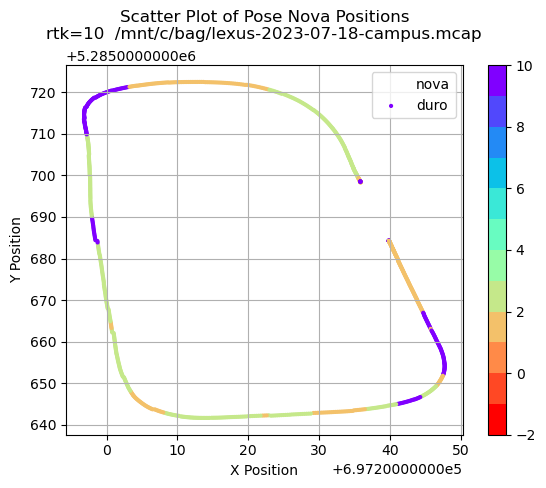

In [2]:
    # int16 STATUS_FIX=0       # Normal fix
    # int16 STATUS_SBAS_FIX=1  # Fixed using a satellite-based augmentation system
    # int16 STATUS_GBAS_FIX=2  #          or a ground-based augmentation system
    # int16 STATUS_DGPS_FIX=18 # Fixed with DGPS
    # int16 STATUS_WAAS_FIX=33 # Fixed with WAAS

    # Ensure status values are numeric
    def get_numeric_status_nova(status):
        try:
            if int(status.status) == 0: # STATUS_FIX=0
                return 10
            elif int(status.status) == 1: # STATUS_SBAS_FIX=1
                return 8
            elif int(status.status) == 2: # STATUS_GBAS_FIX=2
                return 8
            elif int(status.status) == 18: # STATUS_DGPS_FIX=18
                return 8
            elif int(status.status) == 33: # STATUS_WAAS_FIX=33
                return 8
            else:
                return 0
        except ValueError:
            return -2
    

    #   stflags.data = "Invalid";
    #   stflags.data = "Dead Reckoning (DR)";
    #   stflags.data = "Single Point Position (SPP)";
    #   stflags.data = "Differential GNSS (DGNSS)";
    #   stflags.data = "Float RTK";
    #   stflags.data = "Fixed RTK";

    def get_numeric_status_duro(status):
        try:
            if status == "Invalid":
                return 0
            elif status == "Dead Reckoning (DR)":
                return 1
            elif status == "Single Point Position (SPP)":
                return 2
            elif status == "Differential GNSS (DGNSS)":
                return 3
            elif status == "SBAS Position":
                return 4
            elif status == "Float RTK":
                return 9
            elif status == "Fixed RTK":
                return 10
            else:
                return 0
        except ValueError:
            return -2

    # Reduce stat_nova to match the size of pose_nova using linear interpolation
    if len(stat_nova) > len(pose_nova):
        x_old = np.linspace(0, len(stat_nova) - 1, len(stat_nova))
        x_new = np.linspace(0, len(stat_nova) - 1, len(pose_nova))
        stat_nova_reduced = np.interp(x_new, x_old, [get_numeric_status_nova(s.status) for s in stat_nova])
        stat_nova_reduced = [int(value) for value in stat_nova_reduced]
    else:
        stat_nova_reduced = [get_numeric_status_nova(s.status) for s in stat_nova]

    # Reduce stat_duro to match the size of pose_duro using linear interpolation
    if len(stat_duro) > len(pose_duro):
        x_old = np.linspace(0, len(stat_duro) - 1, len(stat_duro))
        x_new = np.linspace(0, len(stat_duro) - 1, len(pose_duro))
        stat_duro_reduced = list(np.interp(x_new, x_old, [int(s.data) for s in stat_duro]))
        stat_duro_reduced = [int(value) for value in stat_duro_reduced]
    else:
        stat_duro_reduced = [get_numeric_status_duro(s.data) for s in stat_duro]


    # Create a rainbow colormap with 12 bins
    cm = plt.get_cmap('rainbow', 12).reversed()
    
    # Plotting the positions
    # Plotting the positions
    plt.figure()
    plt.scatter([p.pose.position.x for p in pose_nova], [p.pose.position.y for p in pose_nova], c=stat_nova_reduced, label='nova', s=8, cmap=cm)
    plt.clim(-2, 10)  # Set color limits
    plt.scatter([p.pose.position.x for p in pose_duro], [p.pose.position.y for p in pose_duro], c=stat_duro_reduced, label='duro', s=4, cmap=cm)
    plt.clim(-2, 10)  # Set color limits
    # print(stat_duro_reduced)
    # print(stat_nova_reduced)

    # Add labels and title
    plt.xlabel('X Position')
    plt.ylabel('Y Position')
    plt.title('Scatter Plot of Pose Nova Positions\nrtk=10  '+ file_name + '\n')
    plt.colorbar()
    plt.legend()
    plt.grid(True)
    plt.show()